In [33]:
from topological_insulator import Problem
import numpy as np
import sys
sys.path.append("/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/")
from mean_field_problem import MeanFieldProblem

In [34]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

In [35]:
def _set_eigenvalues(problem:Problem, Delta_SOC, t, delta, U, occupations):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for i, label_i in enumerate(subs):
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        base = i * 8 
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["interaction"][label_i]["U_p"] = U
        parser["interaction"][label_i]["n_px_up"] = occupations[2+base]
        parser["interaction"][label_i]["n_px_down"] = occupations[3+base]
        parser["interaction"][label_i]["n_py_up"] = occupations[4+base]
        parser["interaction"][label_i]["n_py_down"] = occupations[5+base]
        parser["interaction"][label_i]["n_pz_up"] = occupations[6+base]
        parser["interaction"][label_i]["n_pz_down"] = occupations[7+base]
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings  
            try:
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t + delta
            except:
                pass

In [36]:
location = "bulk"

In [37]:
Delta_SOC = -5
t = -1
delta = 0.832

# n_h = 2
x1 = [0.00000000e+00, 0.00000000e+00, 4.37416395e-01, 4.35105678e-01,
       4.35701241e-01, 4.36684426e-01, 6.13836759e-01, 6.12924236e-01,
       9.34237069e-32, 9.53263562e-32, 4.35105678e-01, 4.37416395e-01,
       4.36684426e-01, 4.35701241e-01, 6.12924236e-01, 6.13836759e-01]

x2 = [0.00000000e+00, 0.00000000e+00, 3.30130724e-01, 3.27778991e-01,
       3.28000583e-01, 3.29609775e-01, 5.80717048e-01, 5.79744028e-01,
       4.17340779e-32, 4.29573046e-32, 3.27778991e-01, 3.30130724e-01,
       3.29609775e-01, 3.28000583e-01, 5.79744028e-01, 5.80717048e-01]

    
cases = {
    0: {"U": 1, "x":x1},
    1: {"U": 3, "x":x2}
}

In [38]:
results = {}
for n, U_dict in enumerate(cases.values()):
    U = U_dict["U"]
    x = U_dict["x"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    _set_eigenvalues(problem, Delta_SOC, t, delta, U, x)
    problem.setup(
        N_r = 10,
        N_k = 400,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [39]:
j_3_2 = [8, 9, 10, 11, 12, 13, 14, 15]
bands = [12, 13, 14, 15]

In [40]:
mean_field_problem = MeanFieldProblem(
        structure_path, structure_name, Delta_SOC=-5,
        t=t, U=0, delta=delta, occupations= np.zeros(16)
)

mean_field_problem.setup(11, 1, 0.05, T = 300, N_h = 2)

## Case 0

In [41]:
g = results[0].geometry
tb_bulk = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

In [42]:
E, DOS = mean_field_problem.density_of_states(
    g, tb_bulk, invariants, mean_field_problem.E_max, 
    mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)

In [43]:
from scipy.optimize import brentq

mu_max = np.max(E) +10
mu_min = np.min(E) -10
# print(mu_max, mu_min)
objective = lambda mu: mean_field_problem._estimate_N_h(E, DOS, mu, 300) - 2
mu, result = brentq(objective, mu_min, mu_max, full_output=True)
print(mu)

5.486258586972125


/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/mean_field_problem.py:113: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp((E - mu)*beta) + 1.0)


Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = 1.0
k=[1.04719755 1.81379936]: delta = 1.0
k=[ 1.04719755 -1.81379936]: delta = -1.0
k=[2.0943951 0.       ]: delta = -1.0
Z2 Invariant - Done!
Z2 Invariant: 0
0.07961633004982183


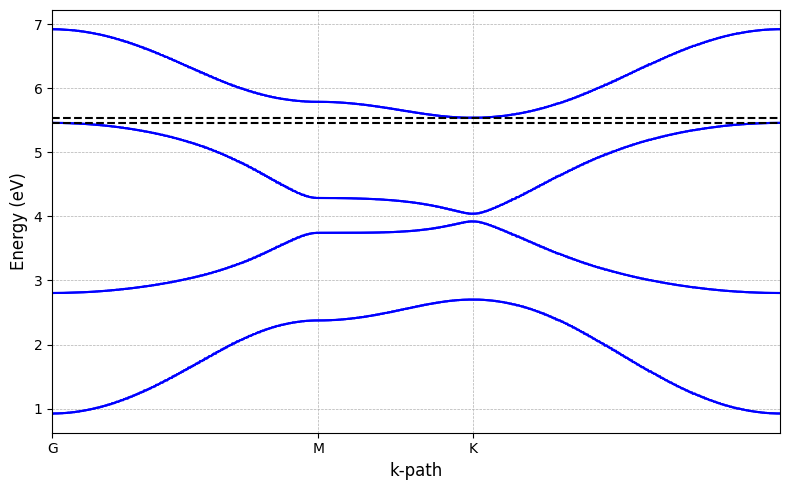

In [44]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(15, 13, only_dE=False)
print(dE)
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])

In [45]:
E_0 = tb_bulk.E_k_dict[f"{g.K_point}"][13]
E_1 = tb_bulk.E_k_dict[f"{g.K_point}"][11]
dE = E_0 - E_1
print(dE)

0.11869970961724263


## Case 1

In [46]:
g = results[1].geometry
tb_bulk = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

In [47]:
E, DOS = mean_field_problem.density_of_states(
    g, tb_bulk, invariants, mean_field_problem.E_max, 
    mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)

In [48]:
from scipy.optimize import brentq

mu_max = np.max(E) +10
mu_min = np.min(E) -10
# print(mu_max, mu_min)
objective = lambda mu: mean_field_problem._estimate_N_h(E, DOS, mu, 300) - 2
mu, result = brentq(objective, mu_min, mu_max, full_output=True)
print(mu)

4.4736368546436


/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/mean_field_problem.py:113: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp((E - mu)*beta) + 1.0)


Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[1.04719755 1.81379936]: delta = -1.0
k=[ 1.04719755 -1.81379936]: delta = -1.0
k=[2.0943951 0.       ]: delta = -1.0
Z2 Invariant - Done!
Z2 Invariant: 0
-0.10070223244193599


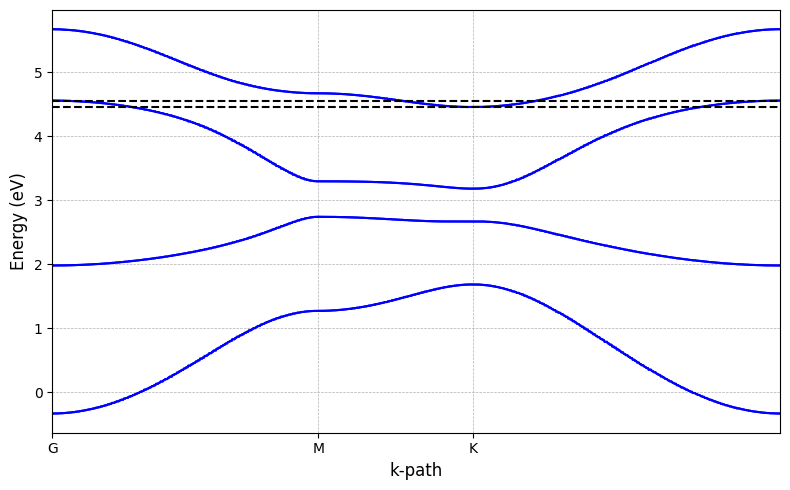

In [49]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(15, 13, only_dE=False)
print(dE)
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])


In [50]:
E_0 = tb_bulk.E_k_dict[f"{g.K_point}"][13]
E_1 = tb_bulk.E_k_dict[f"{g.K_point}"][11]
dE = E_0 - E_1
print(dE)

0.510707012275748
